# 02 Exploratory Data Analysis

EDA uses the **cleaned** sampled monthly-row training subset
(`train_1m_rows_clean.parquet`, produced by `01_preprocessing.ipynb`). Any temporary
imputation or scaling in this notebook is only for visualization or unsupervised exploration, not
model-ready feature engineering.


- **Basic structure/time coverage**: confirm the sample is usable and understand the repeated
  monthly-statement design.
- **Missingness**: preprocessing showed real missing values; EDA checks whether missingness is
  informative before deciding how to model it.
- **Feature groups**: AMEX only reveals prefix-level meanings (`P/B/D/R/S`), so group-level some interpretability.
- **Feature-target signal**: rank raw numeric variables before feature engineering, using simple
  univariate diagnostics rather than a model.
- **Correlation/redundancy**: identify near-duplicate features so feature engineering does not expand
  redundant columns unnecessarily.
- **Categorical target rates**: decide whether categorical levels and missing levels carry signal.
- **K-means/PCA**: satisfy the unsupervised-learning requirement and explore customer structure only;
  these temporary transformations are not final model preprocessing. Depending on results, include/exclude as extra features.


In [1]:
from pathlib import Path
import os

Path('../reports/.matplotlib').mkdir(parents=True, exist_ok=True)
Path('../reports/.cache').mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', '../reports/.matplotlib')
os.environ.setdefault('XDG_CACHE_HOME', '../reports/.cache')
os.environ.setdefault('MPLBACKEND', 'Agg')

import json
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ImportError:
    sns = None

LIGHT_MODE = False
N_SAMPLE_ROWS = 100_000

INTERIM = Path('../data/interim')
REPORTS = Path('../reports/eda')
REPORTS.mkdir(parents=True, exist_ok=True)

def read_rows_for_notebook(path, n_rows):
    if not LIGHT_MODE:
        return pd.read_parquet(path)
    parquet_file = pq.ParquetFile(path)
    batch = next(parquet_file.iter_batches(batch_size=n_rows))
    return batch.to_pandas()

ROWS_PATH = INTERIM / 'train_1m_rows_clean.parquet'
assert ROWS_PATH.exists(), (
    'Cleaned data not found. Run notebooks/01_preprocessing.ipynb first; its '
    'corrections section writes train_1m_rows_clean.parquet.'
)

rows = read_rows_for_notebook(ROWS_PATH, N_SAMPLE_ROWS)
labels = pd.read_parquet(INTERIM / 'train_1m_labels.parquet')
rows = rows.merge(labels, on='customer_ID', how='left', validate='many_to_one')
eda = rows

print(eda.shape)
eda.head()

(1000012, 190)


,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,...,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145,target
0,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,2017-03-01,0.929122,0.382790,0.025782,1.002647,0.005515,0.089799,0.001479,0.005830,...,NaN,NaN,0.003776,0.001808,0.008200,NaN,0.001061,0.000110,0.002629,0
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,2017-04-16,0.918431,0.002224,1.140237,1.008186,0.003287,0.095966,0.007831,0.000861,...,NaN,NaN,0.004046,0.008288,0.001375,NaN,0.009999,0.002669,0.006912,0
2,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,2017-05-07,0.922563,0.567403,0.033713,1.007497,0.005594,0.094655,0.003162,0.010466,...,NaN,NaN,0.007742,0.002693,0.009851,NaN,0.000996,0.003254,0.004469,0
3,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,2017-06-25,0.919253,0.213193,0.031170,1.008534,0.008996,0.099089,0.009513,0.005360,...,NaN,NaN,0.002502,0.003399,0.004284,NaN,0.002642,0.004325,0.006308,0
4,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,2017-07-30,0.901860,0.325467,0.109644,1.005098,0.008041,0.108525,0.000732,0.005484,...,NaN,NaN,0.000275,0.007992,0.006918,NaN,0.009869,0.002979,0.005527,0


## Basic Structure

In [2]:
basic = pd.Series({
    'rows': len(eda),
    'columns': eda.shape[1],
    'customers': eda.customer_ID.nunique(),
    'target_rate': eda.target.mean(),
    'date_min': eda.S_2.min(),
    'date_max': eda.S_2.max(),
})
basic.to_frame('value')

,value
rows,1000012
columns,190
customers,83121
target_rate,0.258937
date_min,2017-03-01 00:00:00
date_max,2018-03-31 00:00:00


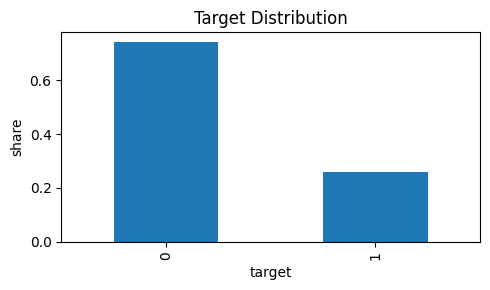

In [3]:
fig, ax = plt.subplots(figsize=(5, 3))
eda['target'].value_counts(normalize=True).sort_index().plot(kind='bar', ax=ax)
ax.set_title('Target Distribution')
ax.set_xlabel('target')
ax.set_ylabel('share')
fig.tight_layout()
fig.savefig(REPORTS / 'target_distribution.png', dpi=160)
plt.show()

## Missingness

In [4]:
missing = eda.drop(columns=['target']).isna().mean().sort_values(ascending=False)
missing.head(30).to_frame('missing_rate')

,missing_rate
D_88,0.998893
D_108,0.994693
D_111,0.994155
D_110,0.994155
B_39,0.993704
D_73,0.989543
B_42,0.987711
D_134,0.963920
D_138,0.963920
D_137,0.963920


In [5]:
missing_by_target = eda.drop(columns=['target']).isna().groupby(eda['target']).mean()
missing_gap = (missing_by_target.loc[1] - missing_by_target.loc[0]).abs().sort_values(ascending=False)
missing_gap.head(20).to_frame('absolute_missingness_gap')

,absolute_missingness_gap
B_17,0.381739
D_53,0.259970
D_56,0.228936
D_77,0.221883
R_26,0.193294
D_42,0.190275
D_49,0.156621
D_50,0.155716
D_132,0.155675
D_106,0.155605


## Feature Groups

In [6]:
def feature_group(col):
    return col.split('_', 1)[0] if '_' in col else 'meta'

feature_cols = [c for c in eda.columns if c not in ['customer_ID', 'S_2', 'target']]
group_summary = []
for group, cols in pd.Series(feature_cols).groupby(pd.Series(feature_cols).map(feature_group)):
    sub = eda[list(cols)]
    group_summary.append({
        'group': group,
        'columns': len(cols),
        'missing_rate': sub.isna().to_numpy().mean(),
    })
group_summary = pd.DataFrame(group_summary).sort_values('group')
group_summary

,group,columns,missing_rate
0,B,40,0.087655
1,D,95,0.226527
2,P,3,0.021494
3,R,28,0.066200
4,S,21,0.055367


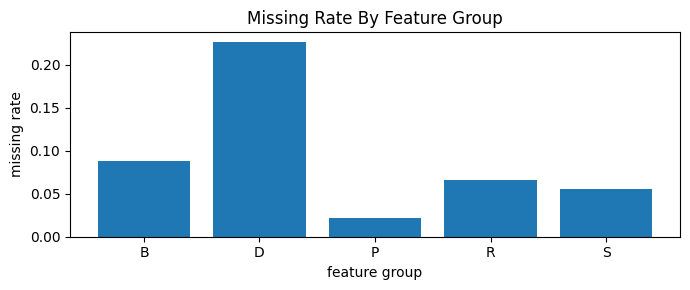

In [7]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(group_summary['group'], group_summary['missing_rate'])
ax.set_title('Missing Rate By Feature Group')
ax.set_xlabel('feature group')
ax.set_ylabel('missing rate')
fig.tight_layout()
fig.savefig(REPORTS / 'missing_rate_by_group.png', dpi=160)
plt.show()

## Time Behavior

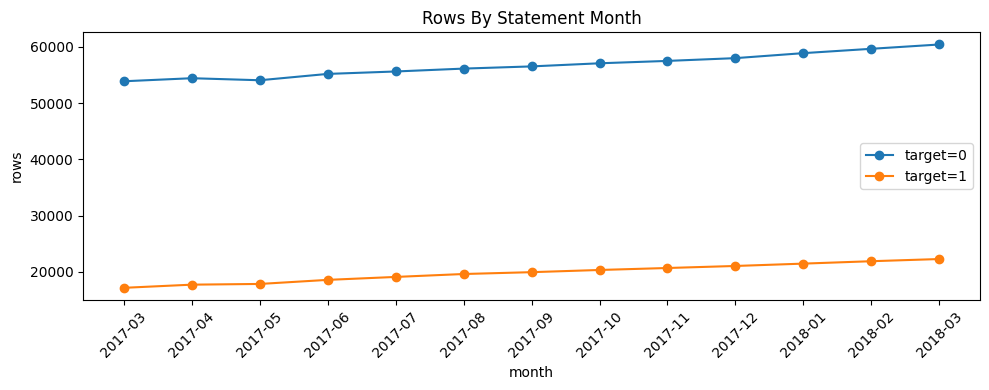

In [8]:
monthly = eda.assign(month=eda['S_2'].dt.to_period('M').astype(str)).groupby(['month', 'target']).size().reset_index(name='rows')
fig, ax = plt.subplots(figsize=(10, 4))
for target, g in monthly.groupby('target'):
    ax.plot(g['month'], g['rows'], marker='o', label=f'target={target}')
ax.set_title('Rows By Statement Month')
ax.set_xlabel('month')
ax.set_ylabel('rows')
ax.tick_params(axis='x', rotation=45)
ax.legend()
fig.tight_layout()
fig.savefig(REPORTS / 'rows_by_month.png', dpi=160)
plt.show()

## Target Relationships And Outliers

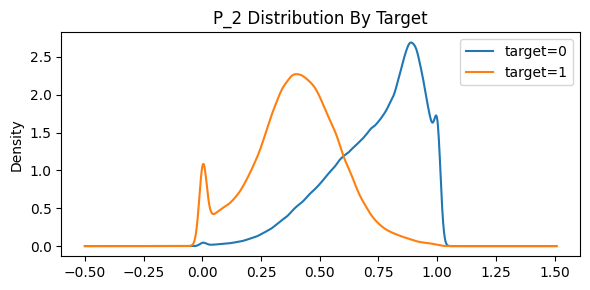

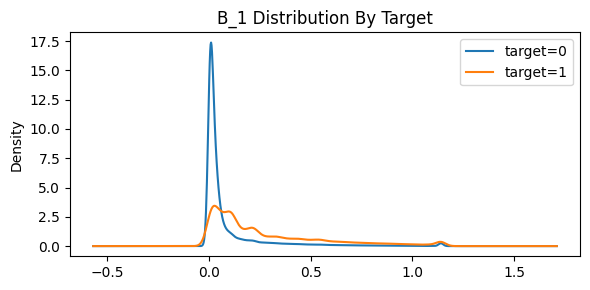

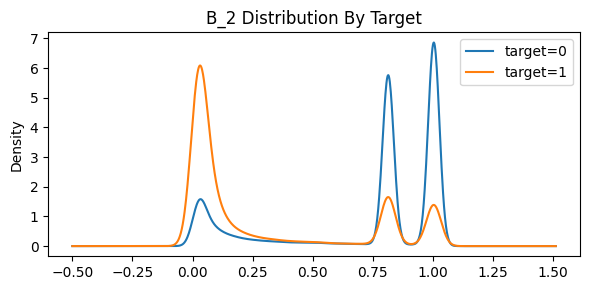

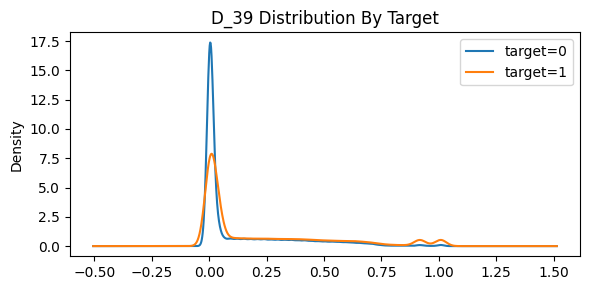

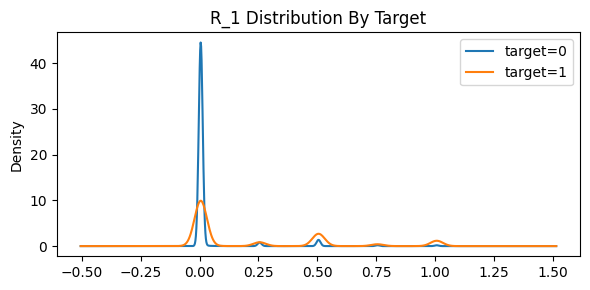

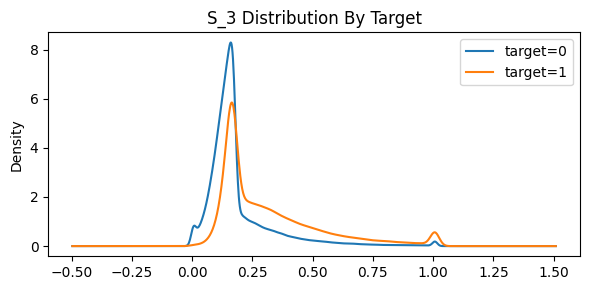

In [9]:
numeric_cols = eda[feature_cols].select_dtypes(include='number').columns.tolist()
candidate_cols = [c for c in ['P_2', 'B_1', 'B_2', 'D_39', 'R_1', 'S_3'] if c in numeric_cols]
for col in candidate_cols:
    fig, ax = plt.subplots(figsize=(6, 3))
    if sns is not None:
        sns.kdeplot(data=eda, x=col, hue='target', common_norm=False, ax=ax)
    else:
        for target, g in eda.groupby('target'):
            g[col].dropna().plot(kind='density', ax=ax, label=f'target={target}')
        ax.legend()
    ax.set_title(f'{col} Distribution By Target')
    fig.tight_layout()
    fig.savefig(REPORTS / f'{col}_by_target.png', dpi=160)
    plt.show()

In [10]:
outlier_summary = eda[numeric_cols].quantile([0.0, 0.01, 0.5, 0.99, 1.0]).T
outlier_summary['range_99_to_01'] = outlier_summary[0.99] - outlier_summary[0.01]
outlier_summary.sort_values('range_99_to_01', ascending=False).head(25)

,0.0,0.01,0.5,0.99,1.0,range_99_to_01
B_1,0.000509,0.000509,0.032497,1.140223,1.140237,1.139714
R_14,0.000103,0.000103,0.005073,1.089845,1.089938,1.089742
D_106,0.000613,0.000613,0.136025,1.087906,1.087919,1.087294
R_7,0.000102,0.000102,0.005148,1.077012,1.077018,1.076910
R_6,0.000102,0.000102,0.005192,1.063798,1.063812,1.063696
S_16,0.000104,0.000104,0.005111,1.059118,1.059132,1.059014
D_73,0.007710,0.007721,0.105393,1.043115,1.043518,1.035394
B_24,0.000105,0.000105,0.005180,1.029764,1.029781,1.029660
D_69,0.000103,0.000103,0.005157,1.026314,1.026321,1.026212
D_56,0.004833,0.004833,0.148703,1.027775,1.027780,1.022942


## Feature–Target Signal

Ranks every numeric feature by its univariate association with the default `target`, using absolute point-biserial correlation and a direction-agnostic univariate AUC. This surfaces which raw features carry predictive signal before any modeling.

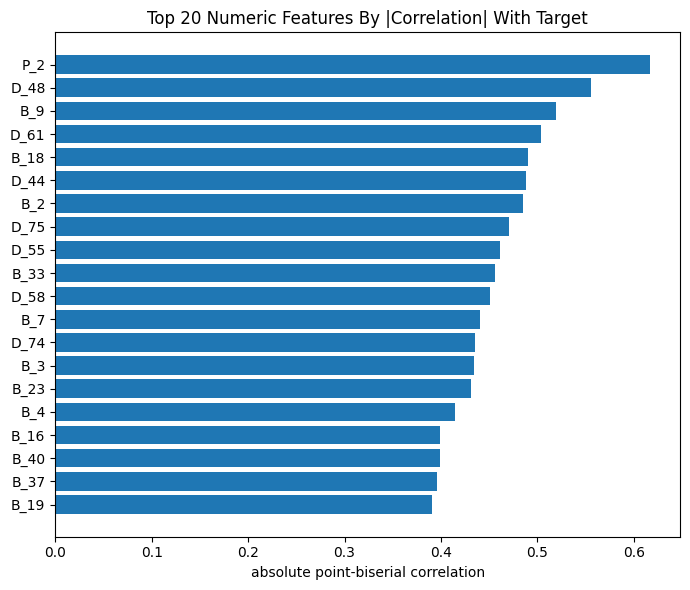

,feature,abs_corr_with_target,univariate_auc,missing_rate
0,P_2,0.617,0.892,0.009
17,D_48,0.556,0.845,0.130
24,B_9,0.519,0.790,0.000
47,D_61,0.504,0.819,0.108
54,B_18,0.490,0.812,0.000
10,D_44,0.488,0.802,0.051
3,B_2,0.485,0.790,0.010
71,D_75,0.471,0.820,0.000
38,D_55,0.461,0.787,0.034
110,B_33,0.456,0.755,0.000


In [11]:
try:
    from sklearn.metrics import roc_auc_score

    y = eda['target'].to_numpy()
    signal_rows = []
    for col in numeric_cols:
        s = eda[col]
        mask = s.notna().to_numpy()
        if mask.sum() < 100:
            continue
        x = s[mask].to_numpy()
        yy = y[mask]
        if x.std() == 0 or len(np.unique(yy)) < 2:
            continue
        corr = np.corrcoef(x, yy)[0, 1]
        auc = roc_auc_score(yy, x)
        signal_rows.append({
            'feature': col,
            'abs_corr_with_target': round(abs(float(corr)), 3),
            'univariate_auc': round(float(max(auc, 1 - auc)), 3),
            'missing_rate': round(float(s.isna().mean()), 3),
        })
    signal = pd.DataFrame(signal_rows).sort_values('abs_corr_with_target', ascending=False)

    top = signal.head(20)
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.barh(top['feature'][::-1], top['abs_corr_with_target'][::-1])
    ax.set_title('Top 20 Numeric Features By |Correlation| With Target')
    ax.set_xlabel('absolute point-biserial correlation')
    fig.tight_layout()
    fig.savefig(REPORTS / 'feature_target_signal.png', dpi=160)
    plt.show()
    display(signal.head(25))
except ImportError:
    print('scikit-learn is not installed; skipping feature-target signal ranking.')

## Correlation Structure (Redundancy)

With ~175 anonymized numeric features, many are near-duplicates. The heatmap shows the overall correlation structure (features <50% missing, temporary median imputation); the table lists pairs with |r| > 0.95 — strong candidates for de-duplication during feature engineering.

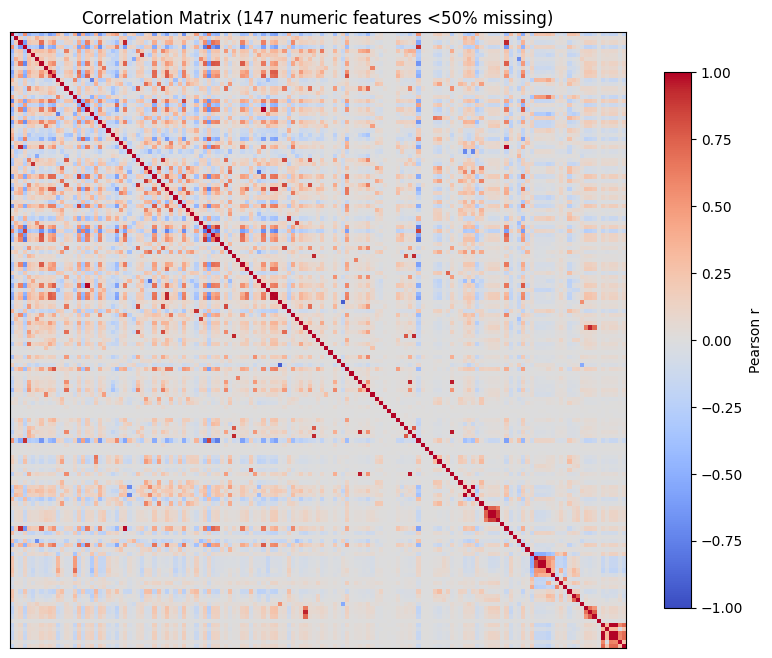

11 feature pairs with |corr| > 0.95 (redundancy candidates)


,feature_a,feature_b,abs_corr
6,D_103,D_104,1.000
9,D_139,D_143,1.000
8,D_139,D_141,0.998
10,D_141,D_143,0.998
0,B_7,B_23,0.996
7,D_118,D_119,0.995
5,S_22,S_24,0.993
1,B_11,B_37,0.990
2,D_74,D_75,0.987
4,R_20,R_24,0.961


In [12]:
complete_numeric = [c for c in numeric_cols if eda[c].isna().mean() < 0.5]
corr_frame = eda[complete_numeric].fillna(eda[complete_numeric].median(numeric_only=True))
corr = corr_frame.corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title(f'Correlation Matrix ({len(complete_numeric)} numeric features <50% missing)')
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
fig.tight_layout()
fig.savefig(REPORTS / 'correlation_matrix.png', dpi=160)
plt.show()

abs_corr = corr.abs().values
cols = corr.columns
pairs = []
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        if abs_corr[i, j] > 0.95:
            pairs.append({'feature_a': cols[i], 'feature_b': cols[j],
                          'abs_corr': round(float(abs_corr[i, j]), 3)})
redundant = pd.DataFrame(pairs).sort_values('abs_corr', ascending=False)
print(f'{len(redundant)} feature pairs with |corr| > 0.95 (redundancy candidates)')
display(redundant.head(20))

## Categorical Features vs Target

For each categorical feature, missingness (`<NaN>`) is treated as its own level. The spread (max − min default rate across levels) measures how discriminative the feature is; bars show the most discriminative ones, with the dashed line marking the overall default rate.

,feature,levels,rate_min,rate_max,spread,missing_rate
6,B_38,7,0.068,0.700,0.632,0.000
5,B_31,2,0.257,0.735,0.478,0.000
4,B_30,3,0.191,0.638,0.446,0.000
8,D_116,2,0.252,0.604,0.352,0.033
9,D_117,7,0.137,0.456,0.319,0.033
7,D_114,2,0.186,0.452,0.266,0.033
10,D_120,2,0.221,0.487,0.266,0.033
11,D_126,3,0.219,0.482,0.263,0.022
1,D_64,4,0.177,0.422,0.245,0.040
3,D_68,7,0.182,0.426,0.244,0.040


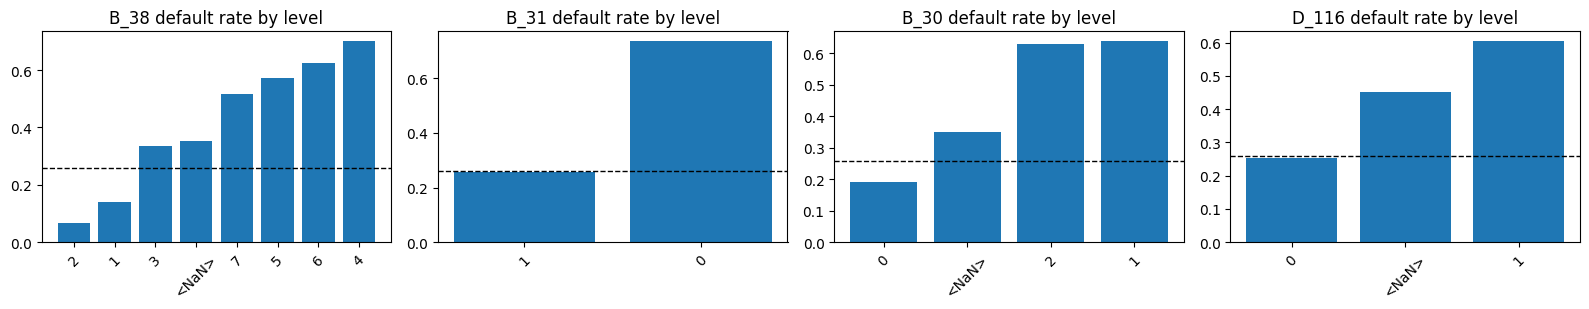

In [13]:
cat_cols = [c for c in feature_cols if c not in numeric_cols]
overall_rate = eda['target'].mean()

cat_spread = []
for col in cat_cols:
    grp = eda[col].fillna('<NaN>')
    rate = eda.groupby(grp)['target'].mean()
    cat_spread.append({
        'feature': col,
        'levels': int(eda[col].nunique()),
        'rate_min': round(float(rate.min()), 3),
        'rate_max': round(float(rate.max()), 3),
        'spread': round(float(rate.max() - rate.min()), 3),
        'missing_rate': round(float(eda[col].isna().mean()), 3),
    })
cat_spread = pd.DataFrame(cat_spread).sort_values('spread', ascending=False)
display(cat_spread)

top_cats = cat_spread.head(4)['feature'].tolist()
fig, axes = plt.subplots(1, len(top_cats), figsize=(4 * len(top_cats), 3.2))
for ax, col in zip(np.atleast_1d(axes), top_cats):
    grp = eda[col].fillna('<NaN>')
    rate = eda.groupby(grp)['target'].mean().sort_values()
    ax.bar(rate.index.astype(str), rate.values)
    ax.axhline(overall_rate, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{col} default rate by level')
    ax.tick_params(axis='x', rotation=45)
fig.tight_layout()
fig.savefig(REPORTS / 'categorical_target_rates.png', dpi=160)
plt.show()

## Customer-Level Clustering (K-Means)

The target is per customer, so we aggregate each customer's statements to one row (mean and last value of every numeric feature, plus statement count) before clustering. Features are winsorized at the 1st/99th percentile and standardized — temporary, for unsupervised exploration only — so a few extreme customers don't dominate. We choose `k` via the elbow, then profile each cluster's default rate and the features that most define it.

/var/folders/4k/6bm67wsj3wd6syhqv58vzbk00000gn/T/ipykernel_451/443292714.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  customer['statement_count'] = eda.groupby('customer_ID').size()


customer-level frame: 83121 customers x 351 features


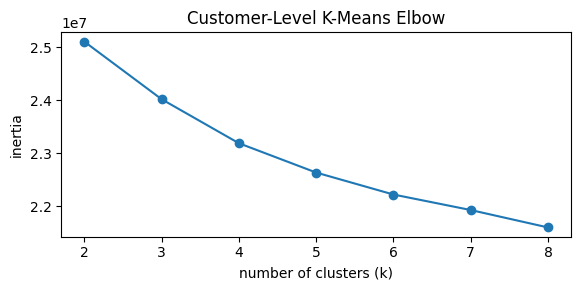

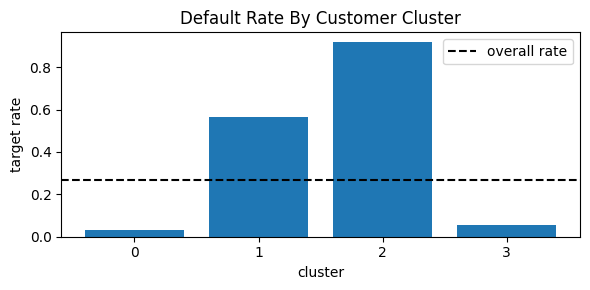

,size,share,target_rate
cluster,,,
0,12632,0.152,0.030
1,26490,0.319,0.565
2,5382,0.065,0.919
3,38617,0.465,0.055


,cluster_0,cluster_1,cluster_2,cluster_3
0,B_5_mean (+1.66 SD),B_2_mean (-1.00 SD),R_5_mean (+3.08 SD),B_33_mean (+0.65 SD)
1,D_92_mean (+1.58 SD),B_18_mean (-1.00 SD),R_4_mean (+3.06 SD),B_18_last (+0.62 SD)
2,S_13_mean (+1.53 SD),B_18_last (-1.00 SD),R_2_mean (+3.03 SD),B_18_mean (+0.62 SD)
3,B_13_mean (+1.51 SD),B_33_mean (-0.99 SD),D_53_last (+2.97 SD),B_33_last (+0.62 SD)
4,B_12_mean (+1.50 SD),B_2_last (-0.96 SD),D_84_last (+2.92 SD),B_16_last (-0.61 SD)
5,B_12_last (+1.49 SD),B_16_last (+0.94 SD),R_7_mean (+2.89 SD),B_9_mean (-0.61 SD)


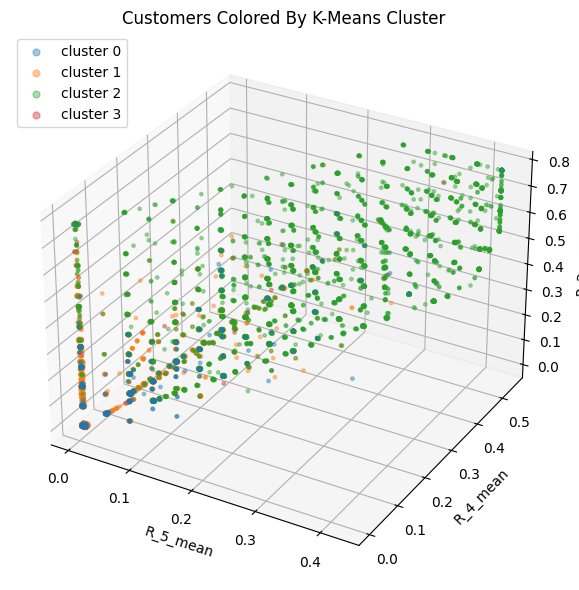

scatter axes (most cluster-explanatory): ['R_5_mean', 'R_4_mean', 'R_2_mean']


In [14]:
try:
    from sklearn.cluster import KMeans
    from sklearn.preprocessing import StandardScaler

    # 1. aggregate statements to one row per customer
    customer = eda.groupby('customer_ID')[numeric_cols].agg(['mean', 'last'])
    customer.columns = [f'{col}_{stat}' for col, stat in customer.columns]
    customer['statement_count'] = eda.groupby('customer_ID').size()
    customer_target = eda.groupby('customer_ID')['target'].first()

    # 2. temporary impute + winsorize + scale (unsupervised exploration only)
    X = customer.fillna(customer.median(numeric_only=True))
    X = X.replace([np.inf, -np.inf], np.nan).dropna(axis=1)
    X = X.clip(lower=X.quantile(0.01), upper=X.quantile(0.99), axis=1)
    X_scaled = StandardScaler().fit_transform(X)
    print(f'customer-level frame: {customer.shape[0]} customers x {customer.shape[1]} features')

    # 3. elbow
    k_values = list(range(2, 9))
    inertias = [KMeans(n_clusters=k, random_state=5241, n_init=10).fit(X_scaled).inertia_ for k in k_values]
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(k_values, inertias, marker='o')
    ax.set_title('Customer-Level K-Means Elbow')
    ax.set_xlabel('number of clusters (k)'); ax.set_ylabel('inertia')
    fig.tight_layout(); fig.savefig(REPORTS / 'kmeans_customer_elbow.png', dpi=160); plt.show()

    # 4. fit final model and profile clusters against the target
    K = 4
    kmeans = KMeans(n_clusters=K, random_state=5241, n_init=10)
    clusters = pd.Series(kmeans.fit_predict(X_scaled), index=customer.index, name='cluster')
    profile = pd.DataFrame({'size': clusters.value_counts().sort_index()})
    profile['share'] = (profile['size'] / len(clusters)).round(3)
    profile['target_rate'] = customer_target.groupby(clusters).mean().round(3)
    profile.to_csv(REPORTS / 'kmeans_customer_profile.csv')

    fig, ax = plt.subplots(figsize=(6, 3))
    ax.bar(profile.index.astype(str), profile['target_rate'])
    ax.axhline(customer_target.mean(), color='black', linestyle='--', label='overall rate')
    ax.set_title('Default Rate By Customer Cluster')
    ax.set_xlabel('cluster'); ax.set_ylabel('target rate'); ax.legend()
    fig.tight_layout(); fig.savefig(REPORTS / 'kmeans_customer_target_rate.png', dpi=160); plt.show()
    display(profile)

    # 5. what defines each cluster: features with the largest standardized deviation
    X_scaled_df = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)
    centroids = X_scaled_df.groupby(clusters).mean()
    defining = {}
    for c in centroids.index:
        top_feats = centroids.loc[c].abs().sort_values(ascending=False).head(6).index
        defining[f'cluster_{c}'] = [f'{f} ({centroids.loc[c, f]:+.2f} SD)' for f in top_feats]
    display(pd.DataFrame(defining))

    # 6. scatter of every customer on the three most cluster-explanatory features
    # (features whose cluster centroids are most spread apart), colored by cluster
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (enables 3d projection)
    axes3 = (centroids.max() - centroids.min()).sort_values(ascending=False).head(3).index.tolist()
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection='3d')
    for c in sorted(clusters.unique()):
        mask = clusters == c
        ax.scatter(X.loc[mask, axes3[0]], X.loc[mask, axes3[1]], X.loc[mask, axes3[2]],
                   s=6, alpha=0.4, label=f'cluster {c}')
    ax.set_xlabel(axes3[0]); ax.set_ylabel(axes3[1]); ax.set_zlabel(axes3[2])
    ax.set_title('Customers Colored By K-Means Cluster')
    ax.legend(markerscale=2, loc='upper left')
    fig.tight_layout()
    fig.savefig(REPORTS / 'kmeans_customer_scatter.png', dpi=160)
    plt.show()
    print(f'scatter axes (most cluster-explanatory): {axes3}')
except ImportError:
    print('scikit-learn is not installed; skipping customer-level clustering.')

## Exploratory PCA

PCA on the same standardized customer-level matrix used for clustering — **exploration only, not a model-ready transform** (a proper, leak-free PCA fit inside cross-validation belongs to feature engineering). The cumulative-variance curve quantifies how compressible the ~190-feature space is (complementing the redundant-pair finding above), and the 2-D projection shows the k-means clusters and the default target in the top two components.

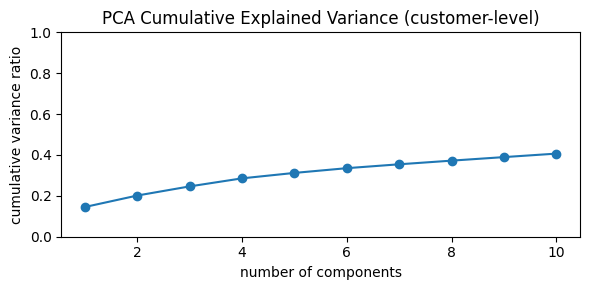

PC1 explains 14.5%; first 2 explain 20.2%; first 10 explain 40.7%


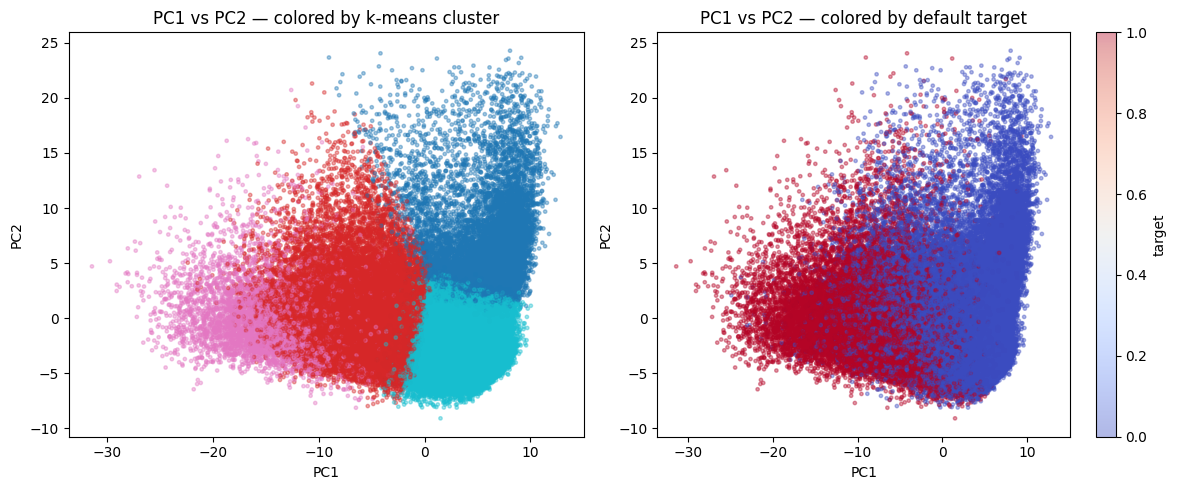

In [15]:
try:
    from sklearn.decomposition import PCA

    if 'X_scaled' not in globals():
        raise RuntimeError('Run the customer-level clustering cell first (it defines X_scaled).')

    pca = PCA(n_components=10, random_state=5241).fit(X_scaled)
    coords = pca.transform(X_scaled)
    cum_var = np.cumsum(pca.explained_variance_ratio_)

    # how concentrated is the variance?
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(range(1, len(cum_var) + 1), cum_var, marker='o')
    ax.set_title('PCA Cumulative Explained Variance (customer-level)')
    ax.set_xlabel('number of components'); ax.set_ylabel('cumulative variance ratio')
    ax.set_ylim(0, 1)
    fig.tight_layout(); fig.savefig(REPORTS / 'pca_explained_variance.png', dpi=160); plt.show()
    print(f'PC1 explains {cum_var[0]:.1%}; first 2 explain {cum_var[1]:.1%}; first 10 explain {cum_var[9]:.1%}')

    # 2-D projection colored by cluster and by target
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    axs[0].scatter(coords[:, 0], coords[:, 1], c=clusters.to_numpy(), cmap='tab10', s=6, alpha=0.4)
    axs[0].set_title('PC1 vs PC2 — colored by k-means cluster')
    sc = axs[1].scatter(coords[:, 0], coords[:, 1], c=customer_target.to_numpy(), cmap='coolwarm', s=6, alpha=0.4)
    axs[1].set_title('PC1 vs PC2 — colored by default target')
    fig.colorbar(sc, ax=axs[1], label='target')
    for ax in axs:
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    fig.tight_layout(); fig.savefig(REPORTS / 'pca_scatter.png', dpi=160); plt.show()
except ImportError:
    print('scikit-learn is not installed; skipping exploratory PCA.')

## PCA And Cluster Interpretation

The PCA projection is useful only if we connect components back to the original anonymized features.
We interpret each component by its largest positive and negative loadings and summarize which AMEX
feature groups (`P/B/D/R/S`) dominate those loadings. Then we describe each k-means cluster by both
(1) where its customers sit in PCA space and (2) which standardized customer-history features are
most above or below average for that cluster.

These labels are intentionally approximate. AMEX feature names are anonymized, so the safest language
is group-level and direction-level: for example, “high recent `D_*`/`B_*` summaries” rather than a
specific business definition.

,component,explained_variance_ratio,positive_side,negative_side,plain_english_read
0,PC1,0.145368,"B_18_mean (+0.12), B_18_last (+0.12), P_2_last...","D_48_mean (-0.12), D_48_last (-0.12), D_55_las...","Higher PC1 means more of: B_18_mean, B_18_last..."
1,PC2,0.056140,"B_13_mean (+0.18), S_13_mean (+0.18), B_12_mea...","S_6_mean (-0.13), S_15_mean (-0.13), S_6_last ...","Higher PC2 means more of: B_13_mean, S_13_mean..."
2,PC3,0.044709,"R_2_mean (+0.18), R_5_mean (+0.18), R_4_mean (...","B_11_mean (-0.09), B_37_mean (-0.09), B_1_mean...","Higher PC3 means more of: R_2_mean, R_5_mean, ..."
3,PC4,0.039390,"D_118_mean (+0.17), D_119_mean (+0.17), D_118_...","D_113_last (-0.14), D_113_mean (-0.14), B_8_me...","Higher PC4 means more of: D_118_mean, D_119_me..."
4,PC5,0.026588,"D_104_mean (+0.18), D_103_mean (+0.18), D_107_...","D_60_mean (-0.13), D_60_last (-0.12), B_37_mea...","Higher PC5 means more of: D_104_mean, D_103_me..."


feature_group,B,D,P,R,S,statement
component,,,,,,
PC1,0.316,0.427,0.027,0.148,0.082,0.000
PC2,0.294,0.387,0.013,0.042,0.260,0.004
PC3,0.280,0.368,0.019,0.298,0.034,0.000
PC4,0.171,0.522,0.027,0.120,0.153,0.006
PC5,0.222,0.625,0.009,0.074,0.070,0.001


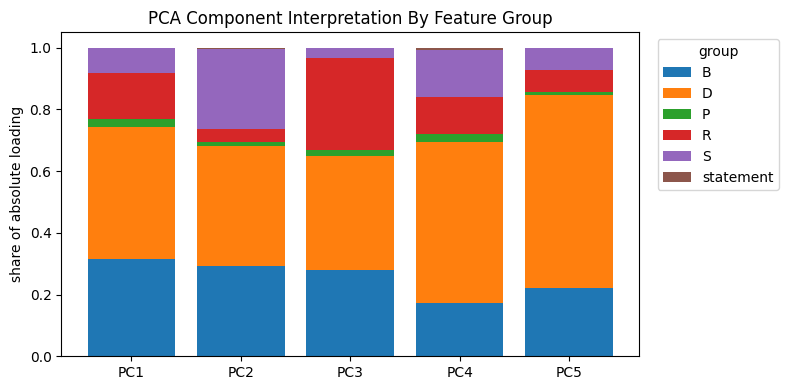

,size,target_rate,PC1,PC2,PC3,share
cluster,,,,,,
0,12632,0.030,5.954,6.550,1.449,0.152
1,26490,0.565,-6.197,0.286,-2.988,0.319
2,5382,0.919,-14.494,-0.006,9.666,0.065
3,38617,0.055,4.324,-2.338,0.229,0.465


,cluster,size,share,target_rate,dominant_pca_position,higher_than_average_features,lower_than_average_features,plain_english_cluster_label
2,2,5382,0.064749,0.919361,PC1 low (-14.49),R_5_mean (+3.08 SD); R_4_mean (+3.06 SD); R_2_...,P_2_last (-1.94 SD); P_2_mean (-1.67 SD); P_3_...,Cluster 2: target rate 91.9%; most elevated in...
1,1,26490,0.318692,0.564817,PC1 low (-6.20),B_16_last (+0.94 SD); B_20_last (+0.89 SD); B_...,B_2_mean (-1.00 SD); B_18_mean (-1.00 SD); B_1...,Cluster 1: target rate 56.5%; most elevated in...
3,3,38617,0.464588,0.054976,PC1 high (+4.32),B_33_mean (+0.65 SD); B_18_last (+0.62 SD); B_...,B_16_last (-0.61 SD); B_9_mean (-0.61 SD); B_9...,Cluster 3: target rate 5.5%; most elevated in ...
0,0,12632,0.151971,0.029845,PC2 high (+6.55),B_5_mean (+1.66 SD); D_92_mean (+1.58 SD); S_1...,S_15_mean (-1.01 SD); S_15_last (-0.83 SD); B_...,Cluster 0: target rate 3.0%; most elevated in ...


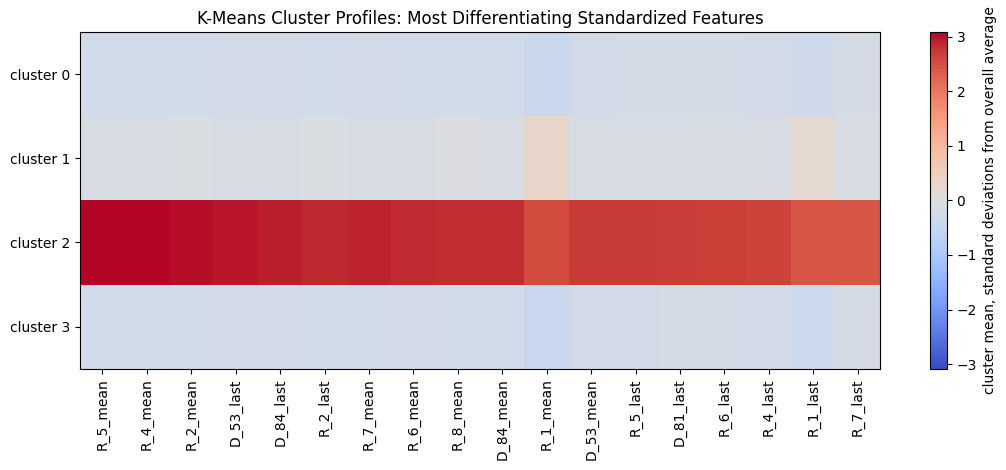

In [16]:
if 'pca' not in globals() or 'coords' not in globals() or 'clusters' not in globals() or 'centroids' not in globals():
    raise RuntimeError('Run the k-means and PCA cells above before interpreting components and clusters.')

def customer_feature_base(feature):
    for suffix in ['_mean', '_last']:
        if str(feature).endswith(suffix):
            return str(feature)[:-len(suffix)]
    return str(feature)

def pca_feature_group(feature):
    base = customer_feature_base(feature)
    return base.split('_', 1)[0] if '_' in base else 'other'

pc_cols = [f'PC{i}' for i in range(1, pca.components_.shape[0] + 1)]
loadings = pd.DataFrame(pca.components_.T, index=X.columns, columns=pc_cols)
loadings_long_rows = []
component_summaries = []

for pc in pc_cols[:5]:
    s = loadings[pc].sort_values()
    negative = s.head(8)
    positive = s.tail(8).sort_values(ascending=False)
    for feature, loading in pd.concat([negative, positive]).items():
        loadings_long_rows.append({
            'component': pc,
            'feature': feature,
            'raw_feature': customer_feature_base(feature),
            'feature_group': pca_feature_group(feature),
            'loading': loading,
            'abs_loading': abs(loading),
            'direction': 'positive' if loading > 0 else 'negative',
        })
    component_summaries.append({
        'component': pc,
        'explained_variance_ratio': pca.explained_variance_ratio_[int(pc[2:]) - 1],
        'positive_side': ', '.join([f'{f} ({v:+.2f})' for f, v in positive.head(5).items()]),
        'negative_side': ', '.join([f'{f} ({v:+.2f})' for f, v in negative.head(5).items()]),
        'plain_english_read': (
            f"Higher {pc} means more of: " + ', '.join(positive.head(3).index) +
            '; lower means more of: ' + ', '.join(negative.head(3).index)
        ),
    })

top_loadings = pd.DataFrame(loadings_long_rows).sort_values(['component', 'abs_loading'], ascending=[True, False])
component_summary = pd.DataFrame(component_summaries)

group_contrib_rows = []
for pc in pc_cols[:5]:
    contrib = loadings[pc].abs().groupby([pca_feature_group(f) for f in loadings.index]).sum()
    contrib = (contrib / contrib.sum()).sort_values(ascending=False)
    for group, share in contrib.items():
        group_contrib_rows.append({'component': pc, 'feature_group': group, 'abs_loading_share': share})
group_contrib = pd.DataFrame(group_contrib_rows)

top_loadings.to_csv(REPORTS / 'pca_component_top_loadings.csv', index=False)
component_summary.to_csv(REPORTS / 'pca_component_interpretation.csv', index=False)
group_contrib.to_csv(REPORTS / 'pca_component_group_contributions.csv', index=False)

display(component_summary)
display(group_contrib.pivot(index='component', columns='feature_group', values='abs_loading_share').fillna(0).round(3))

# Visualize group contribution to the first few PCs.
pivot = group_contrib.pivot(index='component', columns='feature_group', values='abs_loading_share').fillna(0)
fig, ax = plt.subplots(figsize=(8, 4))
bottom = np.zeros(len(pivot))
for group in pivot.columns:
    ax.bar(pivot.index, pivot[group], bottom=bottom, label=group)
    bottom += pivot[group].to_numpy()
ax.set_title('PCA Component Interpretation By Feature Group')
ax.set_ylabel('share of absolute loading')
ax.legend(title='group', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout(); fig.savefig(REPORTS / 'pca_component_group_contributions.png', dpi=160); plt.show()

# Cluster interpretation using PCA coordinates and standardized centroid deviations.
pc_scores = pd.DataFrame(coords[:, :5], index=X.index, columns=pc_cols[:5])
pc_scores['cluster'] = clusters
pc_scores['target'] = customer_target
cluster_pc = pc_scores.groupby('cluster').agg(
    size=('target', 'size'),
    target_rate=('target', 'mean'),
    PC1=('PC1', 'mean'),
    PC2=('PC2', 'mean'),
    PC3=('PC3', 'mean'),
)
cluster_pc['share'] = cluster_pc['size'] / cluster_pc['size'].sum()
cluster_pc.to_csv(REPORTS / 'kmeans_cluster_pc_profile.csv')

interpret_rows = []
for c in centroids.index:
    sorted_dev = centroids.loc[c].sort_values()
    low = sorted_dev.head(5)
    high = sorted_dev.tail(5).sort_values(ascending=False)
    dominant_pc = cluster_pc.loc[c, ['PC1', 'PC2', 'PC3']].abs().idxmax()
    dominant_pc_value = cluster_pc.loc[c, dominant_pc]
    interpret_rows.append({
        'cluster': c,
        'size': int(cluster_pc.loc[c, 'size']),
        'share': cluster_pc.loc[c, 'share'],
        'target_rate': cluster_pc.loc[c, 'target_rate'],
        'dominant_pca_position': f"{dominant_pc} {'high' if dominant_pc_value > 0 else 'low'} ({dominant_pc_value:+.2f})",
        'higher_than_average_features': '; '.join([f'{f} ({v:+.2f} SD)' for f, v in high.items()]),
        'lower_than_average_features': '; '.join([f'{f} ({v:+.2f} SD)' for f, v in low.items()]),
        'plain_english_cluster_label': (
            f"Cluster {c}: target rate {cluster_pc.loc[c, 'target_rate']:.1%}; "
            f"most elevated in {', '.join(high.head(3).index)}; "
            f"lowest in {', '.join(low.head(3).index)}; "
            f"located {dominant_pc_value:+.2f} on {dominant_pc}."
        ),
    })
cluster_interpretation = pd.DataFrame(interpret_rows).sort_values('target_rate', ascending=False)
cluster_interpretation.to_csv(REPORTS / 'kmeans_cluster_interpretation.csv', index=False)
display(cluster_pc.round(3))
display(cluster_interpretation)

# Heatmap of cluster centroids on the most differentiating features.
top_diff_features = (centroids.max() - centroids.min()).sort_values(ascending=False).head(18).index.tolist()
heat = centroids[top_diff_features]
fig, ax = plt.subplots(figsize=(11, 4.8))
im = ax.imshow(heat, aspect='auto', cmap='coolwarm', vmin=-max(abs(heat.min().min()), abs(heat.max().max())), vmax=max(abs(heat.min().min()), abs(heat.max().max())))
ax.set_xticks(range(len(top_diff_features))); ax.set_xticklabels(top_diff_features, rotation=90)
ax.set_yticks(range(len(heat.index))); ax.set_yticklabels([f'cluster {c}' for c in heat.index])
ax.set_title('K-Means Cluster Profiles: Most Differentiating Standardized Features')
fig.colorbar(im, ax=ax, label='cluster mean, standard deviations from overall average')
fig.tight_layout(); fig.savefig(REPORTS / 'kmeans_cluster_differentiating_features.png', dpi=160); plt.show()


## Statistical Association & Distribution Diagnostics

Formal tests of how each feature relates to the default target, beyond the correlation/AUC ranking:

- **Association**: ANOVA F-test (numeric) and chi-square test of independence (categorical).
- **Nonlinearity**: comparing Pearson (linear) and Spearman (monotone). Spearman >> Pearson flags
  *monotone curvature* where a transform like Yeo-Johnson can help linear models.
- **Variance (heteroscedasticity analog)**: Levene's test for equal variance across the two classes.
  Unequal spread means the feature's variability itself is informative and that LDA's equal-covariance
  assumption is violated.

Statements repeat per customer, so treat p-values as descriptive (units aren't fully independent);
the heavier estimators run on a sample.

In [17]:
from sklearn.feature_selection import f_classif
from scipy.stats import chi2_contingency

cat_cols = [c for c in feature_cols if c not in numeric_cols]
Xnum = eda[numeric_cols].fillna(eda[numeric_cols].median(numeric_only=True))
F, _ = f_classif(Xnum, eda['target'])
anova = pd.DataFrame({'feature': numeric_cols, 'anova_F': F}).sort_values('anova_F', ascending=False)
print('Top numeric features by ANOVA F-statistic (vs target):')
display(anova.head(12).round(1).reset_index(drop=True))

chi_rows = []
for c in cat_cols:
    ct = pd.crosstab(eda[c].fillna('missing'), eda['target'])
    stat, _, dof, _ = chi2_contingency(ct)
    chi_rows.append({'feature': c, 'chi2': stat, 'dof': dof})
chi = pd.DataFrame(chi_rows).sort_values('chi2', ascending=False).reset_index(drop=True)
print('Categorical features by chi-square test of independence (vs target):')
display(chi.round(1))

Top numeric features by ANOVA F-statistic (vs target):


,feature,anova_F
0,P_2,606253.2
1,D_48,411400.5
2,B_9,369266.1
3,D_61,321776.0
4,B_18,313902.9
5,B_2,297899.5
6,D_44,289542.8
7,D_75,285512.6
8,D_55,262019.9
9,B_33,256509.4


Categorical features by chi-square test of independence (vs target):


,feature,chi2,dof
0,B_38,223752.7,7
1,B_30,133034.5,3
2,D_120,43950.3,2
3,D_114,41693.2,2
4,D_64,40805.6,4
5,D_68,40160.5,7
6,D_117,35823.7,7
7,D_126,10404.0,3
8,D_116,7387.9,2
9,D_63,7380.3,5


In [18]:
from scipy.stats import spearmanr, pearsonr, levene

samp = eda.sample(min(60_000, len(eda)), random_state=5241)
Xs = samp[numeric_cols].fillna(samp[numeric_cols].median(numeric_only=True))
ys = samp['target'].to_numpy()

pear = np.array([abs(pearsonr(Xs[c], ys)[0]) for c in numeric_cols])
spear = np.array([abs(spearmanr(Xs[c], ys)[0]) for c in numeric_cols])
diag = pd.DataFrame({'feature': numeric_cols, 'pearson': pear, 'spearman': spear})
diag['monotone_nonlinearity'] = diag['spearman'] - diag['pearson']
diag.sort_values('monotone_nonlinearity', ascending=False).to_csv(REPORTS / 'nonlinearity_diagnostics.csv', index=False)

print('Most monotone-nonlinear features (Spearman >> Pearson -> a transform should help linear models):')
display(diag.sort_values('monotone_nonlinearity', ascending=False).head(10).round(3).reset_index(drop=True))

lev_p = np.array([levene(Xs[c][ys == 0], Xs[c][ys == 1]).pvalue for c in numeric_cols])
n_unequal = int((lev_p < 0.01).sum())
print(f"Levene test: {n_unequal}/{len(numeric_cols)} numeric features have UNEQUAL variance across "
      f"classes (p<0.01)\n-> pervasive heteroscedasticity; LDA's equal-covariance assumption is broadly violated.")

Most monotone-nonlinear features (Spearman >> Pearson -> a transform should help linear models):


,feature,pearson,spearman,monotone_nonlinearity
0,B_6,0.324,0.471,0.147
1,D_52,0.227,0.363,0.137
2,B_14,0.141,0.272,0.131
3,D_62,0.338,0.463,0.125
4,B_17,0.060,0.173,0.114
5,S_22,0.217,0.325,0.108
6,B_25,0.210,0.297,0.087
7,S_5,0.098,0.169,0.071
8,S_24,0.210,0.280,0.071
9,B_10,0.386,0.454,0.068


Levene test: 161/175 numeric features have UNEQUAL variance across classes (p<0.01)
-> pervasive heteroscedasticity; LDA's equal-covariance assumption is broadly violated.
